# **Transit + Bikeways Coverage Notebook**
### **Author: Lauren Vo**
**Updated: Dec 16, 2025**

This notebook visualizes **public transit coverage** (GTFS routes + optional stops) and **bikeway infrastructure** (bikeways lines) for **San Diego County**, and summarizes tract-level coverage patterns using TIGER/Line Census Tracts.

**Inputs**
- `data/raw/sandag/Transit_Routes_GTFS.geojson`
- `data/raw/sandag/Bikeways.geojson`
- `data/raw/sandag/Transit_Stops_GTFS.geojson`
- `data/external/tiger_tracts_2023/tl_2023_06_tract.zip`

**Outputs**
- `data/processed/transport/transport_map.html`
- tract-level summaries (e.g., `tract_route_km.csv`, `tract_bikeway_km.csv`, etc.)

**Key data notes / assumptions**
- “GTFS routes” represent routes from a GTFS feed. This may include **multiple agencies** (not MTS-only) unless filtered by `agency_id`.
- Line layers are **clipped to the San Diego County boundary** using tract geometry.
- Tract coverage is computed by intersecting routes/bikeways with tract polygons and summing **km of line geometry within each tract**.
- “Distance to nearest stop” is **centroid-based** (tract centroid → nearest stop point), which is a proxy for access (not travel-time).

In [37]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import folium
    from folium.plugins import MarkerCluster
except ImportError as e:
    raise ImportError(
        "Missing folium. Install it with:\n"
        "  pip install folium\n"
        f"Original error: {e}"
    )

In [38]:
# Project root detection
candidates = [
    Path("."),
    Path(".."),
    Path("../.."),
    Path("../../.."),
    Path("../../../.."),
]

PROJECT_ROOT = None
for cand in candidates:
    cand = cand.resolve()
    if (cand / "data" / "raw" / "sandag").exists() and (cand / "data" / "external" / "tiger_tracts_2023").exists():
        PROJECT_ROOT = cand
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find required directories from this notebook location:\n"
        "- data/raw/sandag\n"
        "- data/external/tiger_tracts_2023\n"
        "Move this notebook inside the Mapping-Youth-Opportunity-Deserts repo and try again."
    )

print("Using PROJECT_ROOT:", PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data"
RAW_SANDAG_DIR = DATA_DIR / "raw" / "sandag"
EXTERNAL_TIGER_DIR = DATA_DIR / "external" / "tiger_tracts_2023"

PROCESSED_TRANSPORT_DIR = DATA_DIR / "processed" / "transport"
PROCESSED_TRANSPORT_DIR.mkdir(parents=True, exist_ok=True)

TRACT_ZIP = EXTERNAL_TIGER_DIR / "tl_2023_06_tract.zip"

ROUTES_GEOJSON = RAW_SANDAG_DIR / "Transit_Routes_GTFS.geojson"
STOPS_GEOJSON  = RAW_SANDAG_DIR / "Transit_Stops_GTFS.geojson"   # optional
BIKEWAYS_GEOJSON = RAW_SANDAG_DIR / "Bikeways.geojson"

OUTPUT_HTML = PROCESSED_TRANSPORT_DIR / "transport_map.html"

TRACT_ZIP, ROUTES_GEOJSON, STOPS_GEOJSON, BIKEWAYS_GEOJSON, OUTPUT_HTML


Using PROJECT_ROOT: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts


(PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/external/tiger_tracts_2023/tl_2023_06_tract.zip'),
 PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/raw/sandag/Transit_Routes_GTFS.geojson'),
 PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/raw/sandag/Transit_Stops_GTFS.geojson'),
 PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/raw/sandag/Bikeways.geojson'),
 PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/processed/transport/transport_map.html'))

In [39]:
if not TRACT_ZIP.exists():
    raise FileNotFoundError(f"Missing: {TRACT_ZIP}")

tracts = gpd.read_file(TRACT_ZIP)
tracts = tracts.set_crs(tracts.crs or "EPSG:4269", allow_override=True).to_crs("EPSG:4326")

tracts_sd = tracts[(tracts["STATEFP"] == "06") & (tracts["COUNTYFP"] == "073")].copy()
tracts_sd = tracts_sd[["GEOID", "NAME", "NAMELSAD", "geometry"]].rename(columns={"GEOID": "tract_geoid"})

print("San Diego tracts:", len(tracts_sd))
tracts_sd.head(3)


San Diego tracts: 737


,tract_geoid,NAME,NAMELSAD,geometry
810,06073008331,83.31,Census Tract 83.31,"POLYGON ((-117.23082 32.94176, -117.23079 32.9..."
819,06073008336,83.36,Census Tract 83.36,"POLYGON ((-117.13793 32.96927, -117.13792 32.9..."
820,06073008337,83.37,Census Tract 83.37,"POLYGON ((-117.14678 32.95497, -117.14657 32.9..."


In [40]:
# County boundary (for clipping)
sd_boundary = tracts_sd.unary_union


/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_23680/2233186692.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  sd_boundary = tracts_sd.unary_union


In [41]:
def load_geo(path: Path, name: str) -> gpd.GeoDataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing {name}: {path}")
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326", allow_override=True)
    else:
        gdf = gdf.to_crs("EPSG:4326")
    # drop empty geometry
    gdf = gdf[gdf.geometry.notna()].copy()
    return gdf

routes = load_geo(ROUTES_GEOJSON, "Transit_Routes_GTFS")
bikeways = load_geo(BIKEWAYS_GEOJSON, "Bikeways")

print("Routes rows:", len(routes))
print("Bikeways rows:", len(bikeways))

# Clip to SD boundary (fast prefilter + precise intersects)
routes_sd = routes[routes.intersects(sd_boundary)].copy()
bikeways_sd = bikeways[bikeways.intersects(sd_boundary)].copy()

print("Routes (SD clip):", len(routes_sd))
print("Bikeways (SD clip):", len(bikeways_sd))


Routes rows: 478
Bikeways rows: 17480
Routes (SD clip): 478
Bikeways (SD clip): 17480


In [42]:
routes.columns

Index(['OBJECTID', 'shape_id', 'route_id', 'route_short_name',
       'route_long_name', 'route_type', 'agency_id', 'route_desc', 'route_url',
       'route_color', 'route_text_color', 'route_type_text', 'RouteShapeName',
       'route_color_RGB', 'route_text_color_RGB', 'Shape_Length', 'geometry'],
      dtype='object')

In [43]:
routes["agency_id"].value_counts()

agency_id
MTS     347
NCTD    131
Name: count, dtype: int64

In [44]:
stops_sd = None
if STOPS_GEOJSON.exists():
    stops = load_geo(STOPS_GEOJSON, "Transit_Stops_GTFS")
    stops_sd = stops[stops.intersects(sd_boundary)].copy()
    print("Stops (SD clip):", len(stops_sd))
else:
    print("Stops file not found; skipping stops layer.")


Stops (SD clip): 6220


In [45]:
def simplify_for_web(lines_gdf: gpd.GeoDataFrame, tol_m: float = 30.0) -> gpd.GeoDataFrame:
    """
    Simplify line geometry for faster Folium rendering.
    tol_m is in meters (we temporarily project to EPSG:3310).
    """
    g = lines_gdf.copy()
    g_3310 = g.to_crs("EPSG:3310")
    g_3310["geometry"] = g_3310["geometry"].simplify(tol_m, preserve_topology=True)
    return g_3310.to_crs("EPSG:4326")

routes_web = simplify_for_web(routes_sd, tol_m=50.0)
bikeways_web = simplify_for_web(bikeways_sd, tol_m=30.0)


In [46]:
# Map center: use SD boundary centroid
sd_center = gpd.GeoSeries([sd_boundary], crs="EPSG:4326").centroid.iloc[0]
m = folium.Map(location=[sd_center.y, sd_center.x], zoom_start=10, control_scale=True)

# Tract outlines (light)
folium.GeoJson(
    tracts_sd,
    name="Census tracts (outlines)",
    style_function=lambda x: {"fillOpacity": 0, "weight": 0.5},
).add_to(m)

# Bikeways (lines)
folium.GeoJson(
    bikeways_web,
    name="Bikeways",
    style_function=lambda x: {"weight": 2},
).add_to(m)

# Transit routes (lines)
folium.GeoJson(
    routes_web,
    name="Transit routes (GTFS)",
    style_function=lambda x: {"weight": 2.5},
).add_to(m)

# Stops (cluster)
if stops_sd is not None and len(stops_sd) > 0:
    cluster = MarkerCluster(name="Transit stops (cluster)", show=False)
    cluster.add_to(m)

    popup_cols = [c for c in ["stop_name", "name", "stop_id"] if c in stops_sd.columns]
    for _, row in stops_sd.iterrows():
        geom = row.geometry
        if geom is None:
            continue
        lat, lon = float(geom.y), float(geom.x)

        lines = []
        for c in popup_cols:
            val = row.get(c)
            if pd.notna(val) and str(val).strip() != "":
                lines.append(f"<b>{c}</b>: {str(val)}")
        html = "<br>".join(lines) if lines else "Stop"

        folium.CircleMarker(
            location=[lat, lon],
            radius=3,
            fill=True,
            fill_opacity=0.7,
            popup=folium.Popup(html, max_width=350),
        ).add_to(cluster)

folium.LayerControl(collapsed=False).add_to(m)

In [47]:
m.save(str(OUTPUT_HTML))
print("Saved:", OUTPUT_HTML)


Saved: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/processed/transport/transport_map.html


## **Visualizations**

### 1) Histograms: **Segment length distributions (routes and bikeways)**
These plots summarize how the line layers are structured.
- A heavy skew toward shorter segments suggests the dataset is represented as many small line pieces.
- Long tails indicate occasional very long segments (often highways/long bikeway corridors or long route shapes).

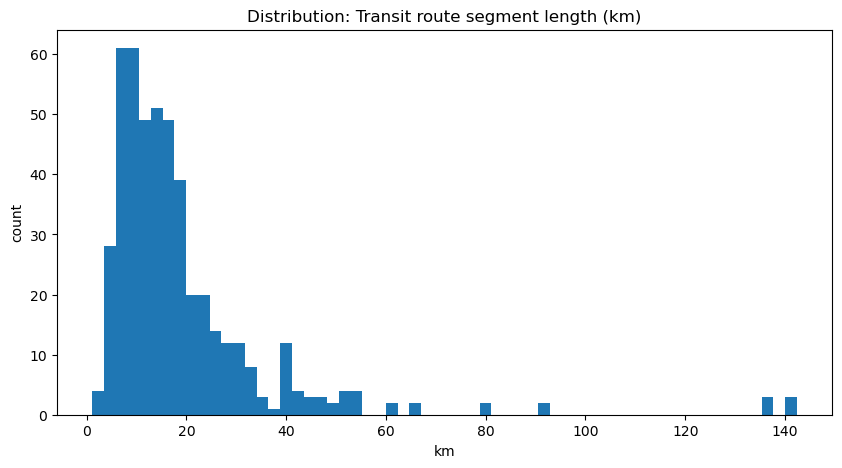

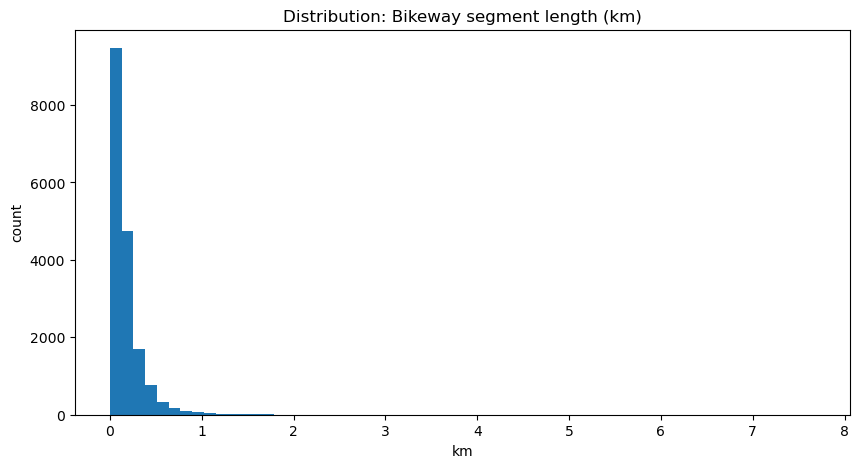

Routes total km (SD clip): 9216.931808493988
Bikeways total km (SD clip): 3054.756801350684


In [48]:
def add_length_km(gdf: gpd.GeoDataFrame) -> pd.Series:
    g = gdf.to_crs("EPSG:3310")
    return (g.geometry.length / 1000.0)

routes_len_km = add_length_km(routes_sd)
bike_len_km = add_length_km(bikeways_sd)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(routes_len_km.dropna(), bins=60)
ax.set_title("Distribution: Transit route segment length (km)")
ax.set_xlabel("km")
ax.set_ylabel("count")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(bike_len_km.dropna(), bins=60)
ax.set_title("Distribution: Bikeway segment length (km)")
ax.set_xlabel("km")
ax.set_ylabel("count")
plt.show()

print("Routes total km (SD clip):", float(routes_len_km.sum()))
print("Bikeways total km (SD clip):", float(bike_len_km.sum()))


### 2) Choropleth: **Transit route coverage by tract (km of routes inside tract)**
This tract-level map shows the amount of transit route geometry within each tract.
- High values indicate tracts with many route corridors or long route shapes passing through.
- Zero or near-zero values indicate potential gaps in corridor coverage (or potentially tracts that are mostly residential/rural with limited service).

### 3) Choropleth: **Bikeway coverage by tract (km of bikeways inside tract)**
This tract-level map shows the amount of bikeway geometry within each tract.
- High values indicate a denser or more extensive bikeway network.
- Zero values highlight tracts with little/no bikeway infrastructure coverage in the dataset.

/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_23680/3576641257.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(palette)


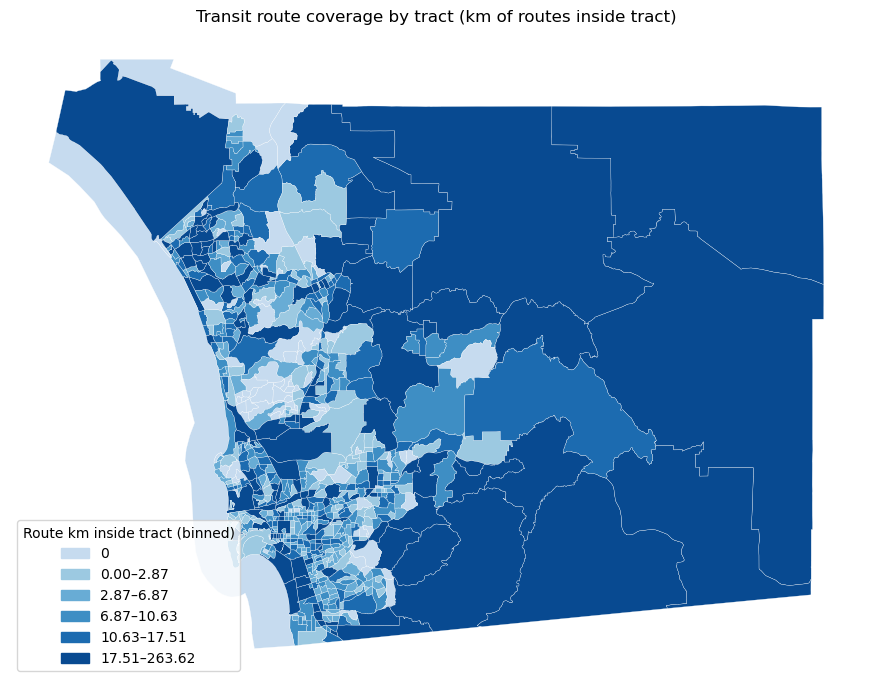

/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_23680/3576641257.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(palette)


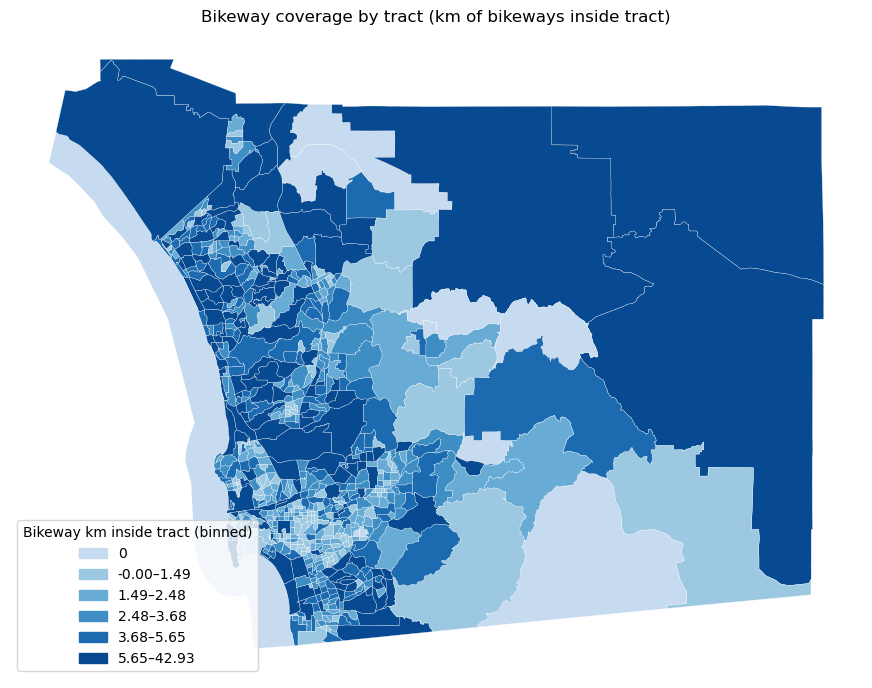

,tract_geoid,NAME,NAMELSAD,geometry,bikeway_km
0,06073008331,83.31,Census Tract 83.31,"POLYGON ((-117.23082 32.94176, -117.23079 32.9...",2.619964
1,06073008336,83.36,Census Tract 83.36,"POLYGON ((-117.13793 32.96927, -117.13792 32.9...",1.918905
2,06073008337,83.37,Census Tract 83.37,"POLYGON ((-117.14678 32.95497, -117.14657 32.9...",2.661972
3,06073011601,116.01,Census Tract 116.01,"POLYGON ((-117.10356 32.6672, -117.10314 32.66...",2.197281
4,06073011602,116.02,Census Tract 116.02,"POLYGON ((-117.10154 32.66203, -117.10133 32.6...",3.909373
...,...,...,...,...,...
732,06073020214,202.14,Census Tract 202.14,"POLYGON ((-117.09313 33.13176, -117.09306 33.1...",5.476769
733,06073000202,2.02,Census Tract 2.02,"POLYGON ((-117.18404 32.74571, -117.18383 32.7...",1.949839
734,06073002712,27.12,Census Tract 27.12,"POLYGON ((-117.08495 32.72367, -117.08476 32.7...",4.004174
735,06073003305,33.05,Census Tract 33.05,"POLYGON ((-117.09511 32.70413, -117.09492 32.7...",1.656143


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def _gradient_colors(n, palette="Blues", start=0.25, end=0.90):
    cmap = cm.get_cmap(palette)
    xs = np.linspace(start, end, n)
    return [mcolors.to_hex(cmap(x)) for x in xs]

def plot_blue_binned_choropleth(gdf, value_col, title, k=6, fmt="{:.2f}", legend_title=None):
    """
    Discrete bins with:
      - a '0' bin
      - (k-1) quantile bins for values > 0
    Uses a blue gradient (discrete) + manual legend.
    """
    g = gdf.copy()
    s = pd.to_numeric(g[value_col], errors="coerce").fillna(0).astype(float)

    pos = s[s > 0]

    if pos.empty:
        labels = ["0"]
        g["_bin"] = pd.Series(["0"] * len(g), index=g.index)
    else:
        q = min(k - 1, pos.nunique())
        pos_bins = pd.qcut(pos, q=q, duplicates="drop")

        intervals = list(pos_bins.cat.categories)
        pos_labels = [f"{fmt.format(iv.left)}–{fmt.format(iv.right)}" for iv in intervals]

        labels = ["0"] + pos_labels

        bin_labels = pd.Series(index=s.index, dtype="object")
        bin_labels[s == 0] = "0"
        bin_labels.loc[pos_bins.index] = pos_bins.map(
            lambda iv: f"{fmt.format(iv.left)}–{fmt.format(iv.right)}"
        )
        g["_bin"] = bin_labels

    # blue gradient for however many bins we ended up with
    colors = _gradient_colors(len(labels), palette="Blues")
    bin_colors = {lab: colors[i] for i, lab in enumerate(labels)}
    g["_plot_color"] = g["_bin"].map(bin_colors).fillna("lightgrey")

    fig, ax = plt.subplots(figsize=(11, 11))
    g.plot(ax=ax, color=g["_plot_color"], linewidth=0.2, edgecolor="white")
    ax.set_title(title)
    ax.set_axis_off()

    handles = [mpatches.Patch(color=bin_colors[l], label=l) for l in labels]
    ax.legend(handles=handles, title=(legend_title or value_col), loc="lower left", frameon=True)

    plt.show()
    return g.drop(columns=["_bin", "_plot_color"], errors="ignore")

plot_blue_binned_choropleth(
    tract_route_km,
    value_col="route_km",
    title="Transit route coverage by tract (km of routes inside tract)",
    legend_title="Route km inside tract (binned)"
)

plot_blue_binned_choropleth(
    tract_bike_km,
    value_col="bikeway_km",
    title="Bikeway coverage by tract (km of bikeways inside tract)",
    legend_title="Bikeway km inside tract (binned)"
)

### 4) Choropleth + table: **Distance to nearest transit stop (km) by tract (centroid-based)**
This approximates tract-level access to stops by measuring the distance from each tract’s centroid to the nearest stop.
- Larger distances suggest tracts where stops are relatively far away for residents (especially meaningful when paired with low route_km).
- This is a proxy measure and can overstate access issues in very large or irregular tracts.


/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_23680/1173035504.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(palette)


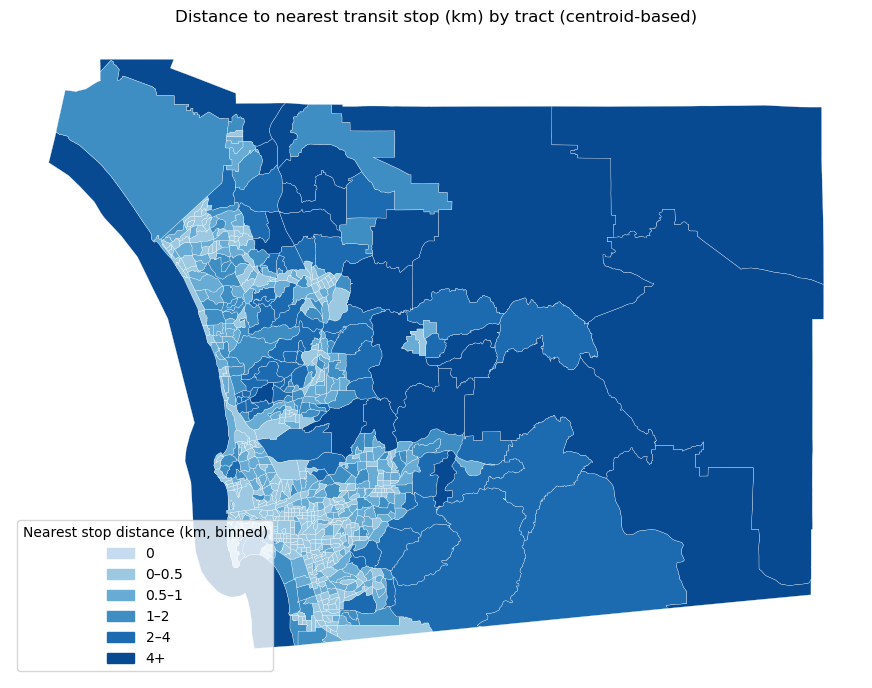

,tract_geoid,nearest_km
189,06073021001,15.685082
318,06073019001,8.604742
146,06073021002,8.392249
467,06073020902,8.319735
396,06073016902,7.819496
289,06073020811,7.559043
281,06073990100,6.474219
485,06073019103,6.385518
675,06073019002,6.043629
371,06073020903,5.871168


In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

if stops_sd is None or len(stops_sd) == 0:
    print("No stops loaded, skipping nearest-stop distance visualization.")
else:
    # Project for distance
    stops_3310 = stops_sd.to_crs("EPSG:3310")

    tract_centroids = tracts_3310.copy()
    tract_centroids["geometry"] = tract_centroids.geometry.centroid

    if not hasattr(gpd, "sjoin_nearest"):
        raise RuntimeError("geopandas.sjoin_nearest not available. Upgrade geopandas.")

    nearest = gpd.sjoin_nearest(
        tract_centroids[["tract_geoid", "geometry"]],
        stops_3310[["geometry"]],
        how="left",
        distance_col="nearest_m"
    )

    tract_stop_dist = tracts_sd.merge(nearest[["tract_geoid", "nearest_m"]], on="tract_geoid", how="left")
    tract_stop_dist["nearest_km"] = (
        (tract_stop_dist["nearest_m"] / 1000.0)
        .replace([np.inf, -np.inf], np.nan)
    )

    # Discrete bins + Tableau-like colors (distance)
    vmax = float(np.nanmax(tract_stop_dist["nearest_km"])) if tract_stop_dist["nearest_km"].notna().any() else 0.0

    bins = [-1, 0, 0.5, 1, 2, 4, max(6, np.ceil(vmax))]
    labels = ["0", "0–0.5", "0.5–1", "1–2", "2–4", f"4+"]

    tract_stop_dist["dist_bin"] = pd.cut(
        tract_stop_dist["nearest_km"].fillna(0),
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    import matplotlib.cm as cm
    import matplotlib.colors as mcolors

    def _gradient_colors(n, palette="Blues", start=0.25, end=0.90):
        cmap = cm.get_cmap(palette)
        xs = np.linspace(start, end, n)
        return [mcolors.to_hex(cmap(x)) for x in xs]

    # Blue gradient (short distance -> light; long distance -> dark)
    blue_colors = _gradient_colors(len(labels), palette="Blues")

    bin_colors = {lab: blue_colors[i] for i, lab in enumerate(labels)}
    tract_stop_dist["plot_color"] = tract_stop_dist["dist_bin"].astype(str).map(bin_colors).fillna("lightgrey")


    # Plot 
    fig, ax = plt.subplots(figsize=(11, 11))

    tract_stop_dist.plot(
        ax=ax,
        color=tract_stop_dist["plot_color"],
        linewidth=0.2,
        edgecolor="white"
    )

    ax.set_title("Distance to nearest transit stop (km) by tract (centroid-based)")
    ax.set_axis_off()

    handles = [mpatches.Patch(color=bin_colors[l], label=l) for l in labels]
    ax.legend(
        handles=handles,
        title="Nearest stop distance (km, binned)",
        loc="lower left",
        frameon=True
    )

    plt.show()

    # Worst gaps (top 15 farthest tracts)
    display(
        tract_stop_dist[["tract_geoid", "nearest_km"]]
        .sort_values("nearest_km", ascending=False)
        .head(15)
    )


In [51]:
# Sanity summaries 
print("\nRow counts:")
print("routes_sd:", len(routes_sd))
print("bikeways_sd:", len(bikeways_sd))
print("stops_sd:", 0 if stops_sd is None else len(stops_sd))

print("\nGeometry types:")
print("Routes geom types:", routes_sd.geometry.geom_type.value_counts().to_dict())
print("Bikeways geom types:", bikeways_sd.geometry.geom_type.value_counts().to_dict())
if stops_sd is not None:
    print("Stops geom types:", stops_sd.geometry.geom_type.value_counts().to_dict())



Row counts:
routes_sd: 478
bikeways_sd: 17480
stops_sd: 6220

Geometry types:
Routes geom types: {'LineString': 478}
Bikeways geom types: {'LineString': 17480}
Stops geom types: {'Point': 6220}
